# Netflix Movies and TV Shows Data Analysis

**This project analyzes Netflix content to identify trends, patterns, and insights using Python, Pandas, Matplotlib, and Seaborn. **

## Dataset Summary

The Netflix dataset contains information about Movies and TV Shows available on Netflix.

The dataset includes details such as title, director, cast, country, release year, rating, and duration.

It contains content from multiple countries and spans many years.

Some columns contain missing values that require cleaning before analysis.

This dataset helps analyze content trends and Netflix's growth over time.

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("netflix_titles.csv")


## Load and Inspect Data

In [7]:

# Basic inspection
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

df.head()





(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
descr

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Cleaning

The following cleaning steps were performed:

1. Missing values in director, cast, and country were replaced with "Unknown".
2. Duplicate records were removed.
3. Date columns were converted into datetime format.
4. Data types were verified and corrected where necessary.

These steps improve data quality and ensure reliable analysis.

In [8]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Convert date column, handling mixed formats
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')

# Check results
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,3


## Question 1

How many Movies and TV Shows are available on Netflix?

In [9]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


Netflix contains more Movies than TV Shows.

## Question 2

Which countries contribute the most Netflix content?

In [10]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


The United States contributes the highest number of titles, followed by other major content-producing countries.

## Question 3

How has Netflix content grown over time?

In [11]:
df['year_added'] = df['date_added'].dt.year
df['year_added'].value_counts().sort_index()

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,11
2014.0,24
2015.0,82
2016.0,429


Netflix content additions increased significantly after 2015.

## Question 4

What are the most common content ratings?

In [12]:
df['rating'].value_counts()

,count
rating,
TV-MA,3211
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


TV-MA and TV-14 are among the most common ratings, indicating a focus on mature audiences.

## Question 5

What is the distribution of release years?

In [13]:
df.groupby('type')['release_year'].mean()

,release_year
type,
Movie,2013.121514
TV Show,2016.605755


Most Netflix content was released after 2000.

# Data Visualizations

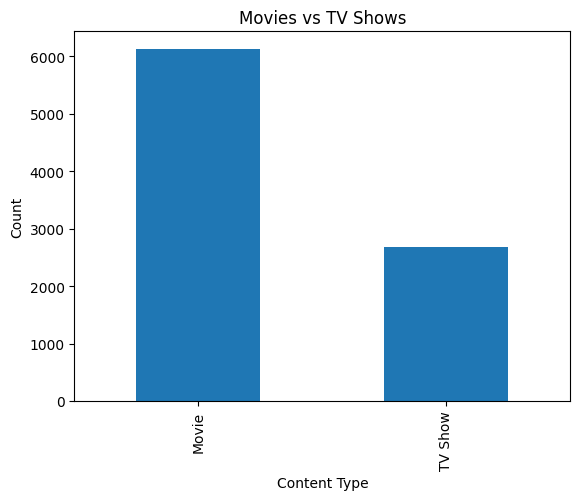

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

df['type'].value_counts().plot(kind='bar')

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

Interpretation:
Movies significantly outnumber TV Shows on Netflix.

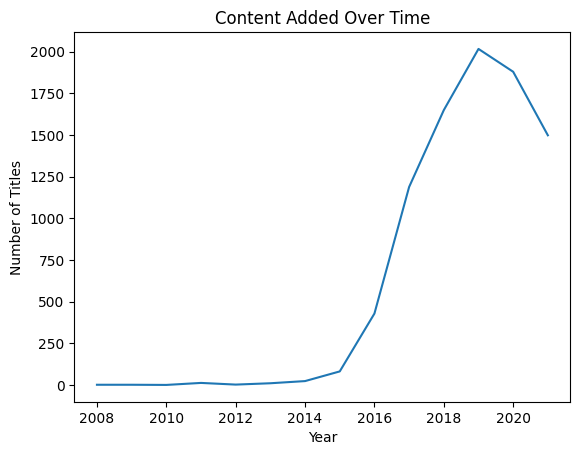

In [15]:
content_by_year = df['year_added'].value_counts().sort_index()

plt.plot(content_by_year.index,
         content_by_year.values)

plt.title("Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

Interpretation:
The number of titles added to Netflix increased rapidly after 2015.

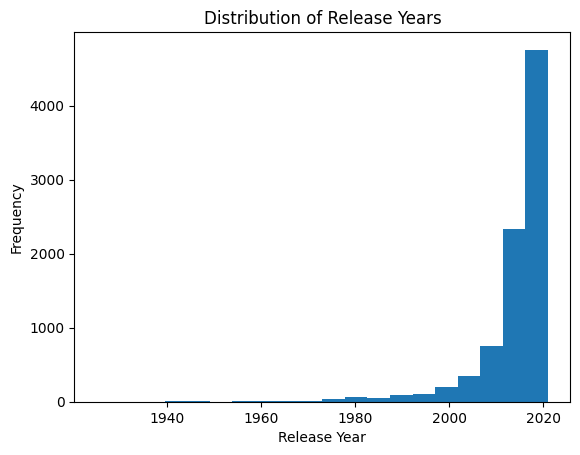

In [16]:
plt.hist(df['release_year'], bins=20)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

Interpretation:
Most content was released in recent years.

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_728/2589254427.py:3: SyntaxWarning: invalid escape sequence '\d'
  movie_df['duration_num'] = movie_df['duration'].str.extract('(\d+)').astype(float)


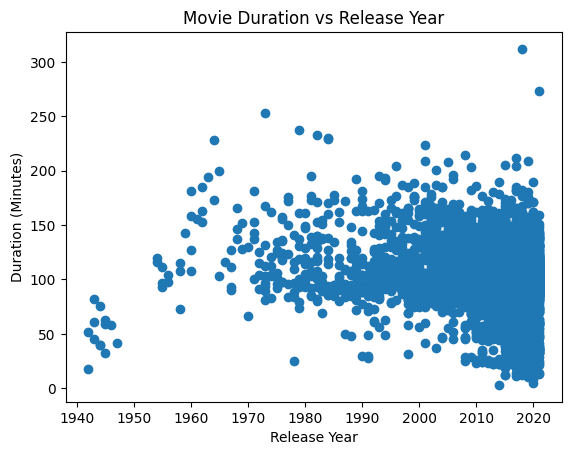

In [17]:
movie_df = df[df['type']=='Movie'].copy()

movie_df['duration_num'] = movie_df['duration'].str.extract('(\d+)').astype(float)

plt.scatter(movie_df['release_year'],
            movie_df['duration_num'])

plt.title("Movie Duration vs Release Year")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")
plt.show()

Interpretation:
Movie duration varies, but most films are concentrated around standard feature lengths.

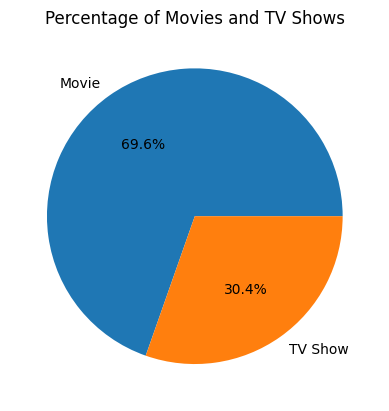

In [18]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Percentage of Movies and TV Shows")
plt.ylabel("")
plt.show()

Interpretation:
Movies occupy the largest share of Netflix's content library.

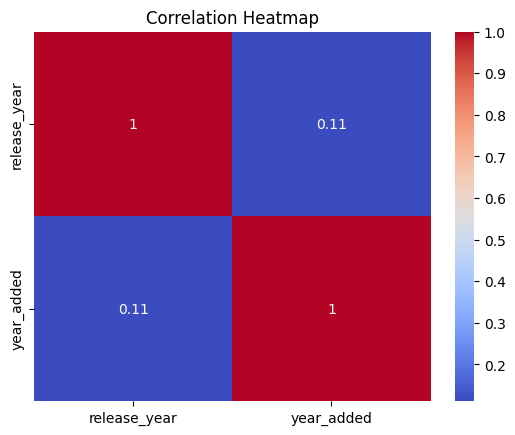

In [19]:
numeric_cols = ['release_year','year_added']

corr = df[numeric_cols].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Interpretation:
The heatmap highlights relationships between numerical variables in the dataset.

# Business Insights Report

1. Movies dominate Netflix's content library, indicating a stronger focus on film content.

2. Netflix experienced rapid catalog growth after 2015, reflecting its global expansion strategy.

3. Most available content is modern, with a large concentration of titles released after 2000.

4. A few countries contribute the majority of Netflix content, suggesting geographic concentration in content production.

5. Mature audience ratings such as TV-MA and TV-14 are the most common, indicating Netflix primarily targets adult and teenage viewers.

# Most Surprising Finding

The most surprising finding was the sharp increase in content additions after 2015.

This suggests that Netflix aggressively expanded its platform and invested heavily in original content and international markets during this period.

# Conclusion

This analysis explored trends in Netflix Movies and TV Shows.

The platform is dominated by movies, and content additions increased significantly after 2015.

Most titles are modern releases and are concentrated among a few major producing countries.

The findings provide useful insights into Netflix's content strategy and global expansion.

Further analysis could explore genre preferences and audience ratings in greater detail.